# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

In [1]:
from sklearn.datasets import fetch_20newsgroups

newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
newsgroupsdocs = newsgroups.data

## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad
1. Utiliza el corpus cargado.
2. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
3. Calcula TF-IDF utilizando sklearn.
4. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [2]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity


print("Número de documentos:", len(newsgroupsdocs))
#Verificar antes y despues de limpieza de texto
vectorizer_raw = TfidfVectorizer()
terms_raw = vectorizer_raw.fit(newsgroupsdocs).get_feature_names_out()

#Vectorizerize the documents
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',  # También puedes usar una lista personalizada
    token_pattern=r'(?u)\b[a-záéíóúñü]{2,}\b'  # solo letras, mínimo 2 caracteres
)
corpusvect = vectorizer.fit_transform(newsgroupsdocs)
terms = vectorizer.get_feature_names_out()
print("Número de términos después de limpieza:", len(terms))
print("Términos sin limpieza:", len(terms_raw))


# Cada columna representa un término.
# corpusvect > 0 da True (1) donde el término aparece.
df_counts = (corpusvect > 0).sum(axis=0)  # matriz 1xN
df_array = np.asarray(df_counts).flatten()  # convertir a array 1D

# Asignar a variable df (como Serie de Pandas)
df = pd.Series(df_array, index=terms, name="Document Frequency")

print(df.sort_values(ascending=False).head(10))

#Pasar a dataframe
df_tfidf = pd.DataFrame.sparse.from_spmatrix(corpusvect, columns=terms)

print(df_tfidf.head())  # primeras filas

# Similaridad entre todos los documentos del corpus
similarity_matrix = cosine_similarity(corpusvect)



# Supongamos que quieres ver los 5 documentos más similares al documento 0
doc_id = 5
similarities = similarity_matrix[doc_id]

# Ordenar de mayor a menor similitud, ignorando el propio doc (índice 0)
similar_indices = similarities.argsort()[::-1][1:6]
print(f"Documentos más similares al documento {doc_id}: {similar_indices}")
print(f"Similitudes: {similarities[similar_indices]}")


Número de documentos: 18846
Número de términos después de limpieza: 86568
Términos sin limpieza: 134410
like      4212
just      4081
don       3894
know      3799
think     3144
does      2988
people    2988
time      2949
use       2705
good      2558
Name: Document Frequency, dtype: int64
   aa  aaa  aaaaa  aaaaaaaaaaaa  \
0   0    0      0             0   
1   0    0      0             0   
2   0    0      0             0   
3   0    0      0             0   
4   0    0      0             0   

   aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaauuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuugggggggggggggggg  \
0                                                  0                                 
1                                                  0                                 
2                                                  0                                 
3                                                  0                                 
4                                                  0              

In [3]:
#Propiedades de la matriz de similitud de coseno
print("Tipo:", type(similarity_matrix))
print("Shape:", similarity_matrix.shape)
print("Ejemplo (fila 0):", similarity_matrix[0][:5])
print("Memoria usada (bytes):", similarity_matrix.nbytes)
print("Memoria usada (MB):", similarity_matrix.nbytes / (1024**2))
# Tipo de dato en cada celda
print("dtype:", similarity_matrix.dtype)

# Acceso rápido a máximos/mínimos
print("Similitud mínima:", similarity_matrix.min())
print("Similitud máxima:", similarity_matrix.max())

# ¿Diagonal 1s? (auto-similitud)
print("¿Diagonal toda 1?:", np.allclose(np.diag(similarity_matrix), 1.0))


Tipo: <class 'numpy.ndarray'>
Shape: (18846, 18846)
Ejemplo (fila 0): [1.         0.         0.02542152 0.         0.        ]
Memoria usada (bytes): 2841373728
Memoria usada (MB): 2709.745147705078
dtype: float64
Similitud mínima: 0.0
Similitud máxima: 1.0000000000000366
¿Diagonal toda 1?: False


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

consulta = input("Ingresa una consulta: ")

#Vectorizar la consulta
consulta_vec = vectorizer.transform([consulta])

# Calcular similitud del coseno entre la consulta y todos los documentos
similitudes = cosine_similarity(consulta_vec, corpusvect)  # Resultado: matriz 1 x n_docs

# Convertir a array plano y mostrar top resultados
similitudes = similitudes.flatten()

# Mostrar los documentos más similares
top_n = 5  # Cambia este valor si quieres más resultados
top_docs_idx = similitudes.argsort()[::-1][:top_n]

#filtrar a mostrar solo documentos done aparece la palabra
palabra_clave = input("Ingresa una palabra clave para filtrar: ")
print("\nTop documentos similares con la palabra clave:")
for i, idx in enumerate(top_docs_idx):
    if palabra_clave.lower() in newsgroupsdocs[idx].lower():
        print(f"\nDocumento #{idx} - Similitud: {similitudes[idx]:.4f}")
        print(newsgroupsdocs[idx][:500], "...")  # Muestra solo primeros 500 caracteres
#total de documentos donde aparece la palabra clave
total_documentos_con_palabra = sum(1 for idx in top_docs_idx if palabra_clave.lower() in newsgroupsdocs[idx].lower())
print(f"\nTotal de documentos con la palabra clave '{palabra_clave}': {total_documentos_con_palabra}")

Ingresa una consulta: chicken
Ingresa una palabra clave para filtrar: chicken

Top documentos similares con la palabra clave:

Documento #1315 - Similitud: 0.2914

But remember that had God extinguished the blasphemous trash of Europe (and
Imperialism with it), the United States would not exist today to put an end
to those "games"....begs the question, which came first, the chicken or the
egg??? ...

Documento #13222 - Similitud: 0.2459
You are right in supposing that the problem is with the XmNcolormap
(XtNcolormap for truly literate beings) not being set.  What you want
to do is start your application with your new colormap.  This can be a
chicken and egg sort of problem, however.  If you look at the Xt FAQ
there is an example that should show how it can be done.  If not, let
me know and maybe I can improve the example.

--pete ...

Documento #15919 - Similitud: 0.2427

Wetteland comes off the DL on April 23rd, and will be evaluated on the 24th.
He is throwing well, and without pain 

In [6]:
#Propiedades del array despues de .flatten()
print("Tipo:", type(similitudes))
print("Shape:", similitudes.shape)
print("Ejemplo (elemento 0):", similitudes[0])
print("Memoria usada (bytes):", similitudes.nbytes)
print("Memoria usada (MB):", similitudes.nbytes / (1024**2))
# Tipo de dato en cada celda
print("dtype:", similitudes.dtype)

# Acceso rápido a máximos/mínimos
print("Similitud mínima:", similitudes.min())
print("Similitud máxima:", similitudes.max())




Tipo: <class 'numpy.ndarray'>
Shape: (18846,)
Ejemplo (elemento 0): 0.0
Memoria usada (bytes): 150768
Memoria usada (MB): 0.1437835693359375
dtype: float64
Similitud mínima: 0.0
Similitud máxima: 0.29139340085569476


## Parte 3: Ranking con BM25

### Actividad

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

In [7]:
!pip install rank_bm25
from rank_bm25 import BM25Okapi

In [8]:
#implementacion de un sistema de recuperacion usando el modelo bm25

tokenized_corpus = [vectorizer.build_tokenizer()(doc) for doc in newsgroupsdocs]

# Initialize BM25 with the tokenized corpus
bm25_doc = BM25Okapi(tokenized_corpus)

# Tokenize the query as well before passing it to get_scores
consulta_tokenized = vectorizer.build_tokenizer()(consulta)
score=bm25_doc.get_scores(consulta_tokenized)
pd.DataFrame({'Document Index': range(len(newsgroupsdocs)), 'bm25score': score})
df.sort_values(ascending=False).head(10)

,Document Frequency
like,4212
just,4081
don,3894
know,3799
think,3144
does,2988
people,2988
time,2949
use,2705
good,2558


## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. Identifica: ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. Sugiere: ¿A qué se podría deber esta diferencia?

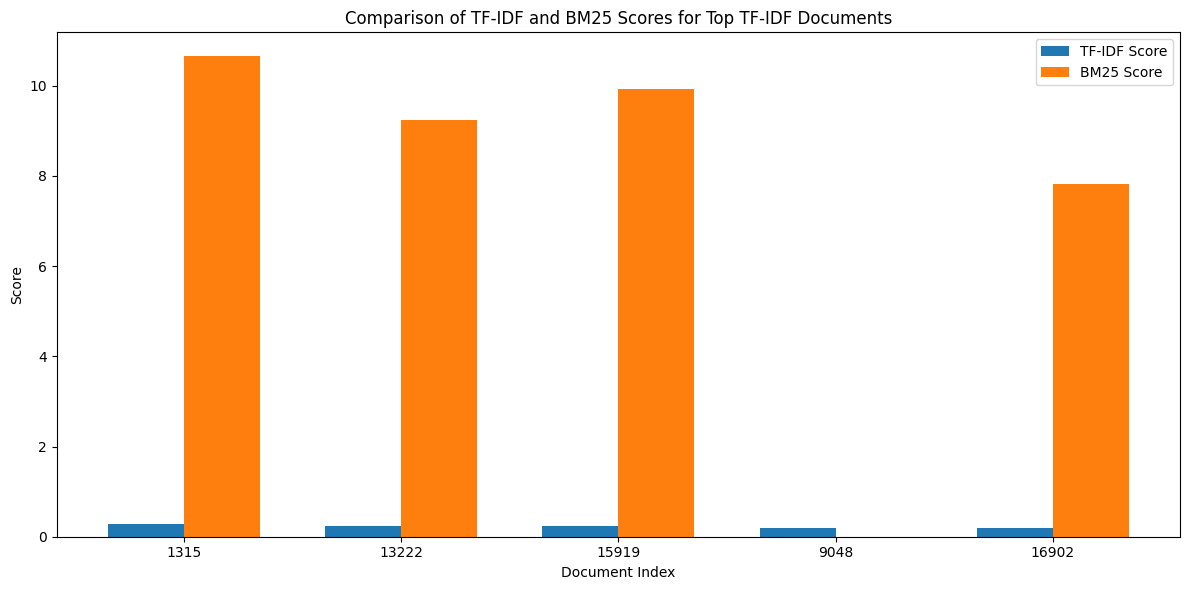

In [10]:
# prompt: Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Get the top N documents by TF-IDF score (using the same query and top_n from Part 2)
tfidf_scores = similitudes[top_docs_idx]
tfidf_doc_indices = top_docs_idx

# Get the BM25 scores for the same documents identified by TF-IDF
bm25_scores_for_tfidf_docs = score[tfidf_doc_indices]

# Create a DataFrame for visualization
df_comparison = pd.DataFrame({
    'Document Index': tfidf_doc_indices,
    'TF-IDF Score': tfidf_scores,
    'BM25 Score': bm25_scores_for_tfidf_docs
})

# Sort by TF-IDF score for consistency with previous output
df_comparison = df_comparison.sort_values(by='TF-IDF Score', ascending=False)

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.35
index = np.arange(len(df_comparison))

bar1 = ax.bar(index, df_comparison['TF-IDF Score'], bar_width, label='TF-IDF Score')
bar2 = ax.bar(index + bar_width, df_comparison['BM25 Score'], bar_width, label='BM25 Score')

ax.set_xlabel('Document Index')
ax.set_ylabel('Score')
ax.set_title('Comparison of TF-IDF and BM25 Scores for Top TF-IDF Documents')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(df_comparison['Document Index'])
ax.legend()

plt.tight_layout()
plt.show()

## Parte 5: Evaluación con consulta relevante

### Actividad

1. Elige una consulta y define qué documentos del corpus deberían considerarse relevantes.
2. Evalúa Precision@3 o MAP para los rankings generados con TF-IDF y BM25.
3. Responde: ¿Cuál modelo da mejores resultados respecto a tu criterio de relevancia?

In [12]:
consulta_eval = "space shuttle accidents"

relevantes = {1425, 1426, 1427, 1428, 1429, 1430, 1431, 1432, 1433, 1434} # EJEMPLO: Reemplaza con índices reales

print(f"Consulta de evaluación: '{consulta_eval}'")
print(f"Documentos relevantes definidos: {relevantes}")

# --- Evaluación con TF-IDF ---

# Vectorizar la consulta de evaluación
consulta_eval_vec = vectorizer.transform([consulta_eval])

# Calcular similitud del coseno para la consulta de evaluación
similitudes_eval_tfidf = cosine_similarity(consulta_eval_vec, corpusvect).flatten()

# Obtener el ranking de documentos por TF-IDF (índices ordenados por similitud)
ranking_tfidf_indices = similitudes_eval_tfidf.argsort()[::-1]

# Función para calcular Precision@K
def precision_at_k(ranking, relevantes, k):
    top_k_indices = set(ranking[:k])
    relevantes_en_top_k = top_k_indices.intersection(relevantes)
    return len(relevantes_en_top_k) / k if k > 0 else 0

# Función para calcular Average Precision (para un query simple)
def average_precision(ranking, relevantes):
    ap = 0.0
    num_relevantes_encontrados = 0
    for i, doc_idx in enumerate(ranking):
        if doc_idx in relevantes:
            num_relevantes_encontrados += 1
            ap += num_relevantes_encontrados / (i + 1)
    # Si no hay documentos relevantes en el ranking, AP es 0. Si hay relevantes pero no se encuentran, AP es 0.
    return ap / len(relevantes) if len(relevantes) > 0 else 0

# Calcular Precision@3 para TF-IDF
p_at_3_tfidf = precision_at_k(ranking_tfidf_indices, relevantes, 3)
print(f"\nTF-IDF Precision@3: {p_at_3_tfidf:.4f}")

# Calcular MAP (MAP es la media de AP para múltiples queries, aquí calculamos AP para una sola query)
ap_tfidf = average_precision(ranking_tfidf_indices, relevantes)
print(f"TF-IDF Average Precision (AP): {ap_tfidf:.4f}")

# --- Evaluación con BM25 ---

# Tokenizar la consulta de evaluación para BM25
consulta_eval_tokenized = vectorizer.build_tokenizer()(consulta_eval)

# Obtener los scores BM25 para la consulta de evaluación
scores_eval_bm25 = bm25_doc.get_scores(consulta_eval_tokenized)

# Obtener el ranking de documentos por BM25 (índices ordenados por score)
ranking_bm25_indices = scores_eval_bm25.argsort()[::-1]

# Calcular Precision@3 para BM25
p_at_3_bm25 = precision_at_k(ranking_bm25_indices, relevantes, 3)
print(f"\nBM25 Precision@3: {p_at_3_bm25:.4f}")

# Calcular Average Precision para BM25
ap_bm25 = average_precision(ranking_bm25_indices, relevantes)
print(f"BM25 Average Precision (AP): {ap_bm25:.4f}")


# --- Responde: ¿Cuál modelo da mejores resultados respecto a tu criterio de relevancia? ---

print("\n--- Conclusión (basada en este ejemplo específico y conjunto de relevantes): ---")
if p_at_3_tfidf > p_at_3_bm25:
    print("TF-IDF tiene una Precision@3 más alta.")
elif p_at_3_bm25 > p_at_3_tfidf:
    print("BM25 tiene una Precision@3 más alta.")
else:
    print("TF-IDF y BM25 tienen la misma Precision@3.")

if ap_tfidf > ap_bm25:
    print("TF-IDF tiene una Average Precision (AP) más alta.")
elif ap_bm25 > ap_tfidf:
    print("BM25 tiene una Average Precision (AP) más alta.")
else:
    print("TF-IDF y BM25 tienen la misma Average Precision (AP).")

# Interpretación:
print("\nLa métrica que da mejores resultados respecto a tu criterio de relevancia")
print("depende de si priorizas la precisión en los primeros resultados (Precision@3)")
print("o la capacidad de encontrar todos los documentos relevantes a lo largo de todo el ranking (Average Precision).")
print("Compara los valores calculados para determinar cuál modelo funcionó mejor en este caso particular.")
print("\nNota: Los 'relevantes' definidos son un ejemplo. Para una evaluación rigurosa, se necesita")
print("un conjunto de datos de evaluación más amplio y validado.")


Consulta de evaluación: 'space shuttle accidents'
Documentos relevantes definidos: {1425, 1426, 1427, 1428, 1429, 1430, 1431, 1432, 1433, 1434}

TF-IDF Precision@3: 0.0000
TF-IDF Average Precision (AP): 0.0030

BM25 Precision@3: 0.0000
BM25 Average Precision (AP): 0.0097

--- Conclusión (basada en este ejemplo específico y conjunto de relevantes): ---
TF-IDF y BM25 tienen la misma Precision@3.
BM25 tiene una Average Precision (AP) más alta.

La métrica que da mejores resultados respecto a tu criterio de relevancia
depende de si priorizas la precisión en los primeros resultados (Precision@3)
o la capacidad de encontrar todos los documentos relevantes a lo largo de todo el ranking (Average Precision).
Compara los valores calculados para determinar cuál modelo funcionó mejor en este caso particular.

Nota: Los 'relevantes' definidos son un ejemplo. Para una evaluación rigurosa, se necesita
un conjunto de datos de evaluación más amplio y validado.
